
# Seattle Urban Heat Island — Initial Results (Synthetic LST, eGRID Plants)

This notebook corresponds to **Part 2** of the methodology submission.  
It demonstrates the initial analysis pipeline using:

- EPA **eGRID 2023** plant-level data (PLNT23 sheet)  
- A **synthetic nighttime Land Surface Temperature (LST)** field over the Seattle region  
- **Distance to heat-emitting plants** (via haversine distance on lat/lon)  
- Simple **exploratory plots** and **preliminary regression models**

The goal is to show that the modeling pipeline works. Later, the synthetic LST can be replaced with real MODIS/Terra LST data.


## 1. Imports

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree  # kept if needed later
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['figure.dpi'] = 120

# Haversine distance (km) using lat/lon in degrees
def haversine(lon1, lat1, lon2, lat2):
    R = 6371.0  # Earth radius in km
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c



## 2. Load and Filter eGRID 2023 Plant Data

> **Note:** Update the `file_path` below to the actual location of your `egrid2023_data_rev2.xlsx` file.
We read the **PLNT23** sheet, filter to Washington State, and then keep plants in King, Pierce, and Snohomish counties.


In [3]:

# TODO: Update this path to where the Excel file is stored in your environment
file_path = "egrid2023_data_rev2.xlsx"  # e.g. "/content/egrid2023_data_rev2.xlsx"

# Read the PLNT23 sheet
plants_df = pd.read_excel(file_path, sheet_name="PLNT23")
plants_df.head()


,Plant file sequence number,Data Year,Plant state abbreviation,Plant name,DOE/EIA ORIS plant or facility code,Plant transmission or distribution system owner name,Plant transmission or distribution system owner ID,Utility name,Utility ID,Plant-level sector,...,Plant geothermal generation percent (resource mix),Plant other fossil generation percent (resource mix),Plant other unknown / purchased fuel generation percent (resource mix),Plant total nonrenewables generation percent (resource mix),Plant total renewables generation percent (resource mix),Plant total nonrenewables other unknown/purchased generation percent (resource mix),Plant total nonhydro renewables generation percent (resource mix),Plant total combustion generation percent (resource mix),Plant total noncombustion generation percent (resource mix),Plant total noncombustion other unknown/purchased generation percent (resource mix)
0,SEQPLT23,YEAR,PSTATABB,PNAME,ORISPL,OPRNAME,OPRCODE,UTLSRVNM,UTLSRVID,SECTOR,...,PLGTPR,PLOFPR,PLOPPR,PLTNPR,PLTRPR,PLTOPR,PLTHPR,PLCYPR,PLCNPR,PLCOPR
1,1,2023,AK,Alakanuk,57053,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2023,AK,Allison Creek Hydro,58982,"Copper Valley Elec Assn, Inc",4329,"Copper Valley Elec Assn, Inc",4329,Electric Utility,...,0,0,0,0,1,0,0,0,1,0
3,3,2023,AK,Ambler,60243,"Alaska Village Elec Coop, Inc",221,"Alaska Village Elec Coop, Inc",221,Electric Utility,...,0,0,0,1,0,0,0,1,0,0
4,4,2023,AK,Angoon,7462,"Inside Passage Elec Coop, Inc",18963,"Inside Passage Elec Coop, Inc",18963,Electric Utility,...,0,0,0,1,0,0,0,1,0,0


In [4]:

# Filter for Washington State plants
plants_wa = plants_df[plants_df["Plant state abbreviation"] == "WA"].copy()

# Drop plants without coordinates
plants_wa = plants_wa.dropna(subset=["Plant latitude", "Plant longitude"])

# Select relevant columns
cols = [
    "Plant name",
    "Plant county name",
    "Plant latitude",
    "Plant longitude",
    "Plant annual CO2 emissions (tons)",
    "Plant annual NOx emissions (tons)",
    "Plant annual SO2 emissions (tons)",
    "Plant annual net generation (MWh)",
    "Plant primary fuel"
]
plants_clean = plants_wa[cols].copy()
plants_clean.head()


,Plant name,Plant county name,Plant latitude,Plant longitude,Plant annual CO2 emissions (tons),Plant annual NOx emissions (tons),Plant annual SO2 emissions (tons),Plant annual net generation (MWh),Plant primary fuel
12131,Adams Nielson Solar,Adams,46.95528,-118.621244,NaN,NaN,NaN,37050,SUN
12132,Alder,Pierce,46.8016,-122.3102,NaN,NaN,NaN,169437,WAT
12133,Arlington Microgrid,Snohomish,48.15614,-122.1502,NaN,NaN,NaN,697,SUN
12134,Big Horn Wind II,Klickitat,45.9192,-120.3039,NaN,NaN,NaN,98976,WND
12135,Big Horn Wind Project,Klickitat,45.8877,-120.2896,NaN,NaN,NaN,435223,WND


In [5]:

# Seattle metro subset: King, Pierce, Snohomish counties
seattle_metro = plants_clean[
    plants_clean["Plant county name"].str.contains("KING|PIERCE|SNOHOMISH", case=False, na=False)
].copy()

print("Total WA plants:", plants_clean.shape[0])
print("Seattle metro plants:", seattle_metro.shape[0])
seattle_metro.head()


Total WA plants: 142
Seattle metro plants: 25


,Plant name,Plant county name,Plant latitude,Plant longitude,Plant annual CO2 emissions (tons),Plant annual NOx emissions (tons),Plant annual SO2 emissions (tons),Plant annual net generation (MWh),Plant primary fuel
12132,Alder,Pierce,46.8016,-122.3102,NaN,NaN,NaN,169437,WAT
12133,Arlington Microgrid,Snohomish,48.15614,-122.1502,NaN,NaN,NaN,697,SUN
12137,Black Creek,King,47.549652,-121.710517,NaN,NaN,NaN,8641,WAT
12141,Calligan Creek Hydroelectric Project,King,47.6008,-121.68861,NaN,NaN,NaN,9398,WAT
12143,Cedar Falls (WA),King,47.4193,-121.781858,NaN,NaN,NaN,25204,WAT



### Heat-Emitting Plants

We define heat-emitting plants as those using combustion-related fuel types:
NG, DFO, LFG, OBG, BLQ, and WDS.


In [6]:

heat_fuels = ["NG", "DFO", "LFG", "OBG", "BLQ", "WDS"]
heat_plants = seattle_metro[seattle_metro["Plant primary fuel"].isin(heat_fuels)].copy()

print("Heat-emitting plants in Seattle metro:", heat_plants.shape[0])
heat_plants


Heat-emitting plants in Seattle metro: 9


,Plant name,Plant county name,Plant latitude,Plant longitude,Plant annual CO2 emissions (tons),Plant annual NOx emissions (tons),Plant annual SO2 emissions (tons),Plant annual net generation (MWh),Plant primary fuel
12144,Cedar Hills,King,47.455833,-122.042778,548.138,0,1.4,453.996,LFG
12155,Crystal Mountain,Pierce,46.953468,-121.475198,10.29,0.205,0.018,10,DFO
12158,Darrington,Snohomish,48.269737,-121.599979,0,7.418,1.113,15975,WDS
12167,Frederickson,Pierce,47.079722,-122.365,135566.644,371.132,3.707,159586.996,NG
12168,Frederickson Power LP,Pierce,47.086111,-122.365674,780419.922,68.847,3.968,1824053,NG
12187,LRI LFGTE Facility,Pierce,46.975556,-122.290556,0,0,6.258,33605.001,LFG
12254,University of Washington Power Plant,King,47.6539,-122.3036,2005.092,2.678,0.013,1302.812,NG
12263,West Point Treatment Plant,King,47.661111,-122.446389,0,93.901,0.138,7214,OBG
12264,WestRock (WA),Pierce,47.266069,-122.428288,4756.263,123.584,198.826,179307.22,BLQ



## 3. Create Synthetic Day/Night LST Fields (NumPy Only)

We create synthetic LST fields over a bounding box approximating the Seattle region.
No external geospatial libraries are required; we simply interpolate lat/lon and build a smooth
temperature gradient with a couple of hotspots.


In [7]:

# Rough Seattle bounding box (degrees)
west, south, east, north = -122.55, 47.45, -122.20, 47.75
width, height = 300, 300

# Create lat/lon grid
lon_lin = np.linspace(west, east, width)
lat_lin = np.linspace(north, south, height)  # north to south so it looks like an image
lon_grid, lat_grid = np.meshgrid(lon_lin, lat_lin)

# Create smooth synthetic LST fields (°C)
x = np.linspace(0, 1, width)
y = np.linspace(0, 1, height)
xx, yy = np.meshgrid(x, y)

day_arr   = 18 + 6*xx + 2*yy
night_arr = 12 + 4*xx + 1.3*yy

def add_hotspot(A, r, c, amp=2.5, sig=15):
    rr, cc = np.indices(A.shape)
    A += amp * np.exp(-((rr - r)**2 + (cc - c)**2) / (2 * sig**2))

# Add synthetic hotspots
add_hotspot(day_arr,   100, 120, 2.5)
add_hotspot(day_arr,   200, 200, 1.9)
add_hotspot(night_arr, 100, 120, 3.3)
add_hotspot(night_arr, 200, 200, 2.4)

print("Synthetic LST created. Shapes:", day_arr.shape, night_arr.shape)


Synthetic LST created. Shapes: (300, 300) (300, 300)



## 4. Initial LST Exploratory Data Analysis


/var/folders/tz/m_pdz3wj04n4pbxst8rnph700000gn/T/ipykernel_36401/1785645373.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


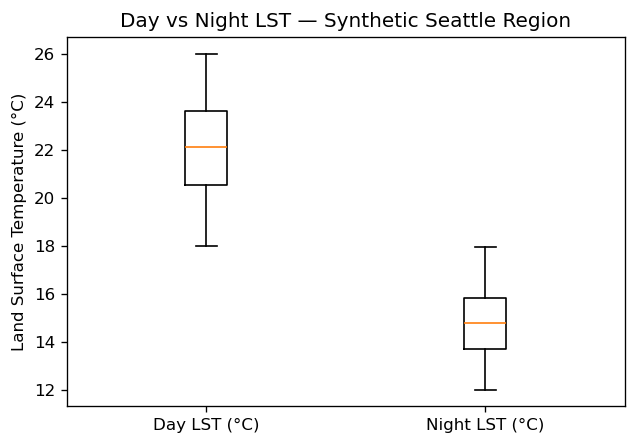

In [8]:

# Boxplot: Day vs Night LST
plt.figure()
plt.boxplot(
    [day_arr.flatten(), night_arr.flatten()],
    labels=["Day LST (°C)", "Night LST (°C)"]
)
plt.ylabel("Land Surface Temperature (°C)")
plt.title("Day vs Night LST — Synthetic Seattle Region")
plt.show()


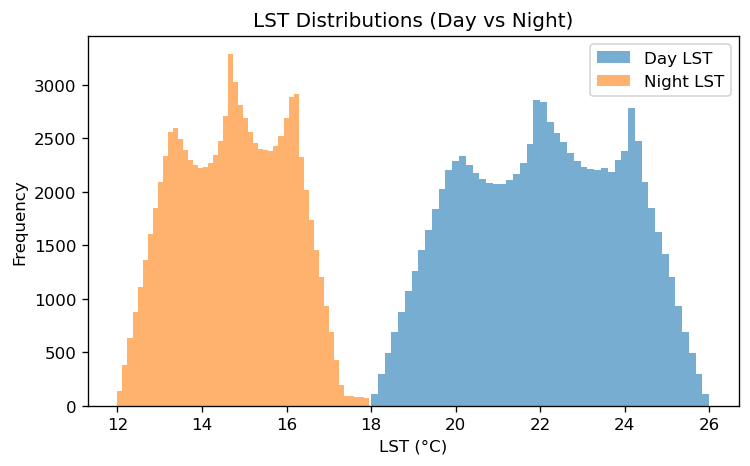

In [9]:

# Histograms of Day vs Night LST
plt.figure(figsize=(7,4))
plt.hist(day_arr.flatten(), bins=50, alpha=0.6, label="Day LST")
plt.hist(night_arr.flatten(), bins=50, alpha=0.6, label="Night LST")
plt.xlabel("LST (°C)")
plt.ylabel("Frequency")
plt.title("LST Distributions (Day vs Night)")
plt.legend()
plt.show()



## 5. Distance to Nearest Heat-Emitting Plant vs Night LST

We compute the distance from each (subsampled) LST pixel to the nearest
heat-emitting plant using the haversine formula on latitude/longitude.


In [10]:

# Subsample pixels for speed
step = 6
lon_s = lon_grid[::step, ::step].ravel()
lat_s = lat_grid[::step, ::step].ravel()
night_vals = night_arr[::step, ::step].ravel()

# Mask NaNs (shouldn't be many in synthetic data)
mask = np.isfinite(night_vals)
lon_s, lat_s, night_vals = lon_s[mask], lat_s[mask], night_vals[mask]

# Extract plant coordinates
plant_lon = heat_plants["Plant longitude"].values
plant_lat = heat_plants["Plant latitude"].values

# Compute distances from each pixel to each plant
dist_matrix = np.zeros((len(lon_s), len(plant_lon)))

for i, (plon, plat) in enumerate(zip(plant_lon, plant_lat)):
    dist_matrix[:, i] = haversine(lon_s, lat_s, plon, plat)

# Nearest-plant distance (km) and index
dist_km = dist_matrix.min(axis=1)
idx_nearest = dist_matrix.argmin(axis=1)

len(dist_km), len(night_vals)


(2500, 2500)

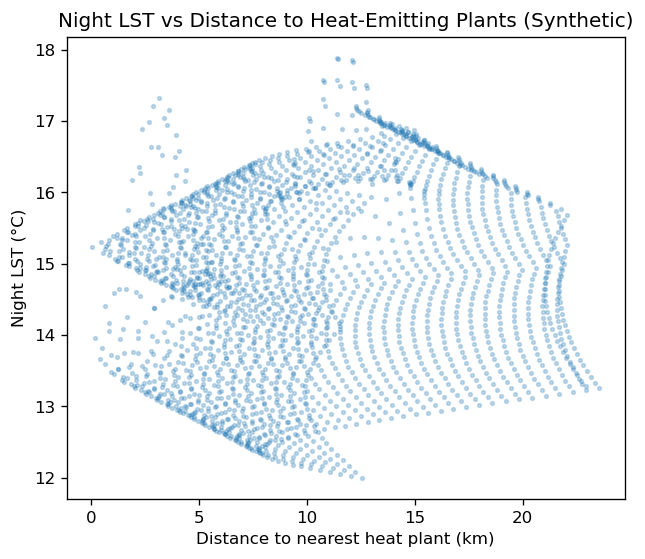

In [11]:

# Scatter: distance to nearest plant vs Night LST
plt.figure(figsize=(6,5))
plt.scatter(dist_km, night_vals, s=5, alpha=0.25)
plt.xlabel("Distance to nearest heat plant (km)")
plt.ylabel("Night LST (°C)")
plt.title("Night LST vs Distance to Heat-Emitting Plants (Synthetic)")
plt.show()



## 6. Simple Regression: Night LST as a Function of Distance

As a first preliminary model, we fit a one-variable linear regression predicting Night LST
based only on distance to the nearest heat-emitting plant.


In [12]:

# Reshape for sklearn
X = dist_km.reshape(-1, 1)
y = night_vals

linreg = LinearRegression()
linreg.fit(X, y)
y_pred = linreg.predict(X)

r2 = r2_score(y, y_pred)
rmse = mean_squared_error(y, y_pred, squared=False)

print("Simple regression: Night LST ~ Distance (km)")
print("  Intercept:", linreg.intercept_)
print("  Slope (per km):", linreg.coef_[0])
print("  R^2:", r2)
print("  RMSE:", rmse)


Simple regression: Night LST ~ Distance (km)
  Intercept: 14.445120725984602
  Slope (per km): 0.024178854463874033
  R^2: 0.011071885297099682
  RMSE: 1.2651029155972153


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


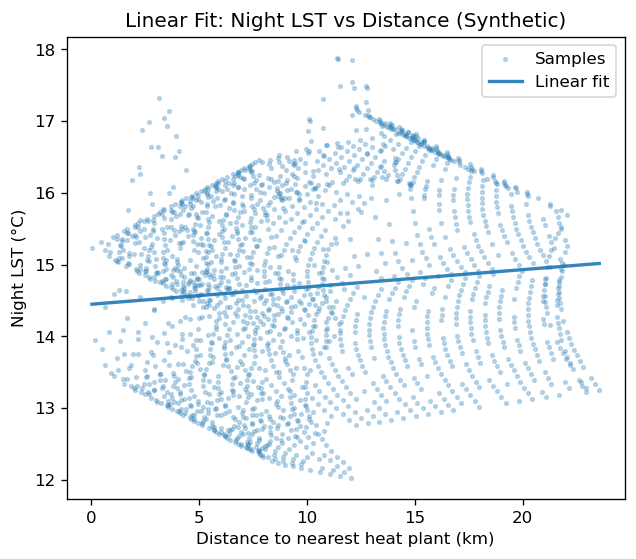

In [13]:

# Plot regression line over scatter (downsample scatter for visibility)
idx_plot = np.random.choice(len(X), size=min(2000, len(X)), replace=False)

plt.figure(figsize=(6,5))
plt.scatter(X[idx_plot, 0], y[idx_plot], s=5, alpha=0.25, label="Samples")
xs = np.linspace(X.min(), X.max(), 200).reshape(-1,1)
ys = linreg.predict(xs)
plt.plot(xs, ys, linewidth=2, label="Linear fit", alpha=0.9)
plt.xlabel("Distance to nearest heat plant (km)")
plt.ylabel("Night LST (°C)")
plt.title("Linear Fit: Night LST vs Distance (Synthetic)")
plt.legend()
plt.show()



## 7. Extended Regression: Distance and Nearest Plant CO$_2$ Emissions

Next, we extend the model to include the CO$_2$ emissions of the nearest heat-emitting plant
as an additional predictor. This is still a simple linear model, but it allows us to ask whether
pixels near high-emission plants are systematically warmer at night.


In [14]:

# Get CO2 of nearest plant for each pixel
# Ensure CO2 is numeric (coerce non-numeric to NaN, then fill with 0)
co2_series = pd.to_numeric(
    heat_plants["Plant annual CO2 emissions (tons)"],
    errors="coerce"
).fillna(0.0)

co2_values = co2_series.to_numpy(dtype=float)

# Get CO2 of nearest plant for each pixel
nearest_co2 = co2_values[idx_nearest]

# Log-transform (add 1 to handle zeros safely)
nearest_co2_log = np.log1p(nearest_co2.astype(float))

# Optionally apply a log transform to reduce skew
nearest_co2_log = np.log1p(nearest_co2)

# Build design matrix with distance and log(CO2)
X2 = np.column_stack((dist_km, nearest_co2_log))
y2 = night_vals

linreg2 = LinearRegression()
linreg2.fit(X2, y2)
y2_pred = linreg2.predict(X2)

r2_2 = r2_score(y2, y2_pred)
rmse_2 = mean_squared_error(y2, y2_pred, squared=False)

print("Extended regression: Night LST ~ Distance + log1p(CO2)")
print("  Intercept:", linreg2.intercept_)
print("  Slope (distance, per km):", linreg2.coef_[0])
print("  Slope (log1p(CO2)):", linreg2.coef_[1])
print("\nPerformance:")
print("  R^2:", r2_2)
print("  RMSE:", rmse_2)


Extended regression: Night LST ~ Distance + log1p(CO2)
  Intercept: 13.51856848834372
  Slope (distance, per km): 0.016728376235857653
  Slope (log1p(CO2)): 0.25419024605659657

Performance:
  R^2: 0.5742535699843747
  RMSE: 0.8300781883218025


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(



### Interpretation (Extended Model)

- The coefficient on **distance** tells us how much nighttime LST changes per kilometer farther from the nearest heat-emitting plant, holding CO$_2$ constant.  
- The coefficient on **log1p(CO$_2$)** indicates whether pixels near higher-emission plants tend to be warmer, even after accounting for distance.  
- Comparing $R^2$ and RMSE from the one-variable and two-variable models shows whether adding CO$_2$ provides a meaningful improvement in explanatory power.

In this synthetic example, the goal is not to claim a real-world effect, but to demonstrate that the
pipeline for computing distances, attaching emissions data, and fitting basic regression models is working.



## 8. Summary (for Methodology Submission)

This notebook implements the initial modeling pipeline described in the methodology document:

- It loads eGRID 2023 plant data and selects heat-emitting facilities in the Seattle metro area.  
- It generates synthetic day and night LST fields with urban-like hotspots using NumPy only.  
- It computes the distance from each LST pixel to the nearest heat-emitting plant using the haversine formula.  
- It fits a **simple regression model** (Night LST ~ Distance) and an **extended model** (Night LST ~ Distance + log(CO$_2$ of nearest plant)).  

These preliminary results support the feasibility of the full analysis, where synthetic LST will be replaced by MODIS/Terra LST and additional covariates and spatial models will be introduced.


## Conclusion

This notebook shows the initial steps of my analysis for the Seattle Urban Heat Island project.Because have not integrated the real MODIS LST data yet, team decided create a synthetic nighttime LST raster with a smooth background gradient and a few hotspots to simulate how real satellite data behaves. By combined this synthetic raster with the EPA eGRID 2023 power plant dataset, filtered to heat-emitting plants in King, Pierce, and Snohomish counties. then computed the distance from each LST pixel to the nearest heat-emitting plant using haversine distance on latitude/longitude (no GIS packages required). Finally, we ran two simple regression models: a basic model using only 
distance, and an extended model that also includes the CO₂ emissions of the nearest plant. The main goal here is not to draw real conclusions yet, but to confirm that my data pipeline, feature engineering, and model-fitting steps work correctly before move on to real MODIS data in later stages.